# Setup

In [ ]:
# Заставляем ноутбук обновлять импорты автоматически (если ты изменил код в src/)
%load_ext autoreload
%autoreload 2
import os # noqa: E402
import sys # noqa: E402
from pathlib import Path # noqa: E402
from omegaconf import OmegaConf # noqa: E402
from hydra.utils import instantiate # noqa: E402
from src.utils.notebook_setup import init_nlp_notebook # noqa: E402

# 1. Вычисляем корень проекта ОДИН РАЗ
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Регистрируем все резолверы ГЛОБАЛЬНО
# Теперь ${paths.data_dir} будет подтягиваться из конфига,
# а если Hydra падает, мы подставляем ${PROJECT_ROOT}
OmegaConf.register_new_resolver("project_root", lambda: str(PROJECT_ROOT))
OmegaConf.register_new_resolver("hydra", lambda path: str(PROJECT_ROOT), replace=True)
OmegaConf.register_new_resolver("now", lambda *args: "now", replace=True)

# 3. Инициализируем Hydra
cfg = init_nlp_notebook()

# 4. Трюк: принудительно подменяем переменную paths, если она не разрешилась
# Это поможет конфигу увидеть, где лежат данные, без правок yaml-файлов
if "paths" not in cfg:
    cfg.paths = OmegaConf.create()
cfg.paths.data_dir = str(PROJECT_ROOT / "data")

# 5. Инициализируем токенизатор
tokenizer = instantiate(cfg.model.tokenizer).build()
print(f"Environment ready. Root: {PROJECT_ROOT}")
print(f"Model: {cfg.model.model_name}")

NLP Environment ready. Root: c:\fake-news-detection-ml-system


c:\fake-news-detection-ml-system\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.core.models.tokenization:Загрузка токенизатора: DeepPavlov/rubert-base-cased
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/DeepPavlov/rubert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DeepPavlov/rubert-base-cased/4036cab694767a299f2b9e6492909664d9414229/tokenizer_config.json "HTTP/1.1 20

Environment ready. Root: c:\fake-news-detection-ml-system
Model: DeepPavlov/rubert-base-cased


# Data Loading

In [2]:
from src.core.data.builder import NLPDataModule # noqa: E402

# Конфиг уже содержит все пути благодаря правкам выше
datamodule = NLPDataModule(data_cfg=cfg.data, tokenizer=tokenizer)

datamodule.prepare_data()
datamodule.setup(stage="fit")

dataset = datamodule.train_dataset
print(f"Dataset schema: {dataset.column_names}")

INFO:src.core.data.builder:Начинаем загрузку и обработку сырых данных...
INFO:src.core.data.fetcher:Kaggle датасет найден локально: c:\fake-news-detection-ml-system\data/raw\email_text.csv. Скачивание пропущено.
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/csv/csv.py "HTTP/1.1 200 OK"
Saving the dataset (1/1 shards): 100%|██████████| 1731/1731 [00:00<00:00, 157395.51 examples/s]
INFO:src.core.data.builder:Данные успешно очищены и сохранены в c:\fake-news-detection-ml-system\data/processed\nlp_dataset_cleaned_75f99743


Dataset schema: ['label', 'text']


In [3]:
# После datamodule.setup(stage="fit")
print(f"Train: {len(datamodule.train_dataset)} примеров")
print(f"Val:   {len(datamodule.val_dataset)} примеров")

# Баланс классов — КРИТИЧНО для классификации спама
from collections import Counter # noqa: E402
labels = datamodule.train_dataset["label"]
counter = Counter(labels)
total = len(labels)
print("\nБаланс классов (train):")
for label, count in sorted(counter.items()):
    print(f"  класс {label}: {count} ({count/total*100:.1f}%)")

Train: 13847 примеров
Val:   1731 примеров

Баланс классов (train):
  класс 0: 10006 (72.3%)
  класс 1: 3841 (27.7%)


Дисбаланс имеется, не сильно критичный но можно попробовать изменить баланс весов классов и посмотреть на Recall класса спама, если он вырастет, то взвешивание помогло

# Tokenization & Sequence Length Analysis

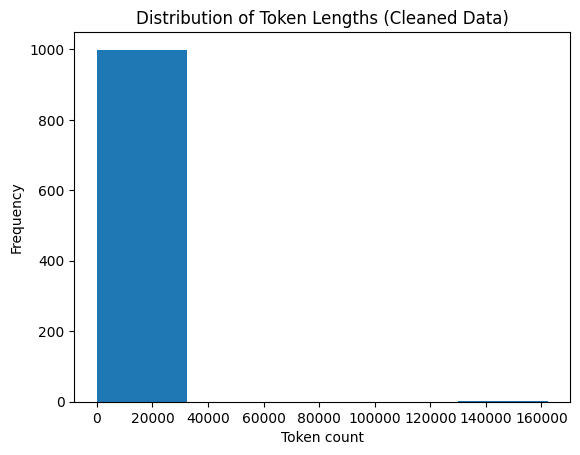

In [6]:
import matplotlib.pyplot as plt # noqa: E402
# Извлекаем тексты из правильной колонки, указанной в конфиге
text_col = cfg.data.text_column
sample_texts = dataset.select(range(min(1000, len(dataset))))[text_col]

# Пример анализа длин
lengths = [len(tokenizer.encode(text)) for text in sample_texts]

plt.hist(lengths, bins=5)
plt.title("Distribution of Token Lengths (Cleaned Data)")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import numpy as np # noqa: E402

lengths = [len(tokenizer.encode(text)) for text in sample_texts]

print(f"Медиана:       {np.median(lengths):.0f} токенов")
print(f"95-й перцентиль: {np.percentile(lengths, 95):.0f} токенов")
print(f"99-й перцентиль: {np.percentile(lengths, 99):.0f} токенов")
print(f"Максимум:      {max(lengths)} токенов")
print(f"Обрезается при max_length=512: {sum(1 for l in lengths if l > 512)} примеров ({sum(1 for l in lengths if l > 512)/len(lengths)*100:.1f}%)")

Медиана:       280 токенов
95-й перцентиль: 1782 токенов
99-й перцентиль: 5084 токенов
Максимум:      162328 токенов
Обрезается при max_length=512: 265 примеров (26.5%)


С дефолтной длинной в 512 обрезается довольно много примеров, с другой стороны медиана на 280, если взять 256 примерно половина не пострадает вообще, необходимы тесты, если на 256 качество не падает, то это значительно ускорит обучение, также попробовать увеличить длину и посмотреть на увеличение(если оно будет) метрик

# Artifact & Noise Identification

In [8]:
import pandas as pd # noqa: E402
import re # noqa: E402

# 1. Инстанциируем объект (он не возвращает данные, он лишь настраивает параметры)
fetcher = instantiate(cfg.data.source)

# 2. Вызываем метод загрузки (посмотри, как он называется, обычно это fetch() или load())
# Я предполагаю, что это fetch(), так как лог выше говорил: INFO:src.core.data.fetcher:Скачивание...
raw_datasets = fetcher.load() 

# 3. Теперь проверяем, что вернулось
if isinstance(raw_datasets, dict):
    raw_train = raw_datasets.get("train", raw_datasets)
else:
    raw_train = raw_datasets
raw_sample_data = raw_train.select(range(min(5000, len(raw_train))))[cfg.data.text_column]

# 1. Определяем паттерны "шума" 
noise_patterns = {
    "extra_whitespace": r"\s{2,}",
    "html_tags": r"<[^>]+>",
    "non_printable": r"[^\x20-\x7E\u0400-\u04FF\n]", 
    "truncated_lines": r"^\s*\.\.\.\s*$",
}

def analyze_noise(text_list):
    stats = {}
    for name, pattern in noise_patterns.items():
        count = sum(1 for text in text_list if re.search(pattern, text))
        stats[name] = count / len(text_list)
    return stats

# Применяем на выборке сырых данных
noise_report = analyze_noise(raw_sample_data)

# Выводим отчет в виде таблицы
df_noise = pd.DataFrame.from_dict(noise_report, orient='index', columns=['percentage'])
print("--- Noise Artifacts Report (RAW DATA) ---")
print(df_noise)

# Если процент высокий — нужно проверить, что твои классы-наследники BaseCleaner это исправляют.

INFO:src.core.data.fetcher:Kaggle датасет найден локально: c:\fake-news-detection-ml-system\data/raw\email_text.csv. Скачивание пропущено.
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/csv/csv.py "HTTP/1.1 200 OK"


--- Noise Artifacts Report (RAW DATA) ---
                  percentage
extra_whitespace      0.0000
html_tags             0.0000
non_printable         0.0582
truncated_lines       0.0000


In [ ]:
clean_texts = datamodule.train_dataset[cfg.data.text_column]
clean_noise_report = analyze_noise(clean_texts[:5000])

df_comparison = pd.DataFrame({
    "raw": noise_report,
    "cleaned": clean_noise_report
})
df_comparison["delta"] = df_comparison["raw"] - df_comparison["cleaned"]
print(df_comparison)

                     raw  cleaned   delta
extra_whitespace  0.0000   0.0000  0.0000
html_tags         0.0000   0.0000  0.0000
non_printable     0.0582   0.0798 -0.0216
truncated_lines   0.0000   0.0000  0.0000


Требуется дополнительное исследование, предварительно клинер только добавляет non_printable символы но, вероятнее всего очищенная и сырая выборки не одинаковые, попробую одинаковые

In [ ]:
# Берём одни и те же тексты из RAW
raw_texts_for_comparison = raw_train.select(range(500))[cfg.data.text_column]

# Прогоняем через cleaner вручную
cleaner = instantiate(cfg.data.cleaner)

cleaned_texts = []
for text in raw_texts_for_comparison:
    result = text
    for c in cleaner.cleaners:  # если pipeline — итерируем
        result = c.clean(result)  # или как называется метод
    cleaned_texts.append(result)

# Сравниваем на одних и тех же
raw_report = analyze_noise(raw_texts_for_comparison)
clean_report = analyze_noise(cleaned_texts)

df = pd.DataFrame({"raw": raw_report, "cleaned": clean_report})
df["delta"] = df["raw"] - df["cleaned"]
print(df)

                   raw  cleaned  delta
extra_whitespace  0.00     0.00    0.0
html_tags         0.00     0.00    0.0
non_printable     0.06     0.06    0.0
truncated_lines   0.00     0.00    0.0


На одинаковых, ничего не меняется

In [13]:
from src.core.data.cleaners import *
# Принудительно пересобрать кэш
datamodule2 = NLPDataModule(data_cfg=cfg.data, tokenizer=tokenizer)
datamodule2.prepare_data()  # force_reprocess=True или просто удали папку processed

# Прогнать те же 500 примеров
raw_texts = raw_train.select(range(500))[cfg.data.text_column]

cleaner = TextCleaningPipeline(cleaners=[
    RegexCleaner(pattern="<.*?>", replacement=" "),
    RegexCleaner(pattern="[^\x20-\x7E\u0400-\u04FF\n\t]", replacement=""),
    RegexCleaner(pattern=r"\s+", replacement=" "),
])

cleaned = [cleaner(t) for t in raw_texts]

raw_report = analyze_noise(raw_texts)
clean_report = analyze_noise(cleaned)

df = pd.DataFrame({"raw": raw_report, "cleaned": clean_report})
df["delta"] = df["raw"] - df["cleaned"]
print(df)
# non_printable delta теперь должна быть > 0

INFO:src.core.data.builder:Нашли кэш данных: c:\fake-news-detection-ml-system\data/processed\nlp_dataset_cleaned_75f99743. Очистка пропущена.


                   raw  cleaned  delta
extra_whitespace  0.00      0.0   0.00
html_tags         0.00      0.0   0.00
non_printable     0.06      0.0   0.06
truncated_lines   0.00      0.0   0.00


Проблема с non_printable решена с помощью pattern="[^\x20-\x7E\u0400-\u04FF\n\t]", replacement=""

# Quality Audit

In [10]:
def check_round_trip(text, tokenizer):
    tokens = tokenizer.encode(text)
    decoded = tokenizer.decode(tokens, skip_special_tokens=False)
    return tokens, decoded

# Берем сложные примеры из ОЧИЩЕННОГО датасета
clean_sample_texts = dataset.select(range(5))[cfg.data.text_column]

print(f"{'Original':<30} | {'Round-Trip (Decoded)'}")
print("-" * 80)

for text in clean_sample_texts:
    tokens, decoded = check_round_trip(text, tokenizer)
    print(f"{text[:25]+'...':<30} | {decoded[:50]+'...'}")

# ПРОВЕРКА СПЕЦ-ТОКЕНОВ
# Убедись, что твои маркеры начала/конца не превращаются в [UNK]
test_marker = "<|start_header_id|>"
print(f"\nMarker '{test_marker}' encoding: {tokenizer.encode(test_marker)}")

Original                       | Round-Trip (Decoded)
--------------------------------------------------------------------------------
on die escapenumber escap...   | [CLS] on die escapenumber escapenumber escapenumbe...
hello i've subscribed to ...   | [CLS] hello i ' ve subscribed to this list for abo...
at escapenumber escapenum...   | [CLS] at escapenumber escapenumber am escapenumber...
from kenneth forster date...   | [CLS] from kenneth forster date august escapenumbe...
niranjan sivakumar implem...   | [CLS] niranjan sivakumar implementing declarative ...

Marker '<|start_header_id|>' encoding: [101, 160, 286, 17136, 271, 230, 10773, 56911, 230, 13116, 286, 164, 102]


In [11]:
# Примеры которые типичны для спама — спецсимволы, капс, числа
test_cases = [
    "FREE MONEY!!! Click here NOW: http://spam.com",
    "Уважаемый клиент, ваш счёт заблокирован. Позвоните: +7-999-123-45-67",
    "normal email about a meeting tomorrow at 3pm",
]

print(f"{'Оригинал':<45} | {'Токенов':>8} | {'[UNK]':>6}")
print("-" * 65)
for text in test_cases:
    tokens = tokenizer.encode(text)
    decoded = tokenizer.decode(tokens, skip_special_tokens=True)
    unk_count = tokens.count(tokenizer.unk_token_id)
    print(f"{text[:43]:<45} | {len(tokens):>8} | {unk_count:>6}")

Оригинал                                      |  Токенов |  [UNK]
-----------------------------------------------------------------
FREE MONEY!!! Click here NOW: http://spam.c   |       26 |      0
Уважаемый клиент, ваш счёт заблокирован. По   |       25 |      0
normal email about a meeting tomorrow at 3p   |       18 |      0


Каких либо действий не требуется